# Importation et définition de variables globales

In [20]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import ale_py
import gc
import seaborn as sns
import pickle

from agent.rainbow_agent import DQNAgent as Rainbow

from agent.no_noisy_no_categ_agent import DQNAgent as NoNoisyNoCateg
from reseaux.nn_no_noisy_no_categ_no_duel import Network as NnNoThree
from reseaux.nn_no_noisy_no_categ import Network as NnDueling

from agent.no_noisy_agent import DQNAgent as NoNoisy
from reseaux.nn_no_noisy_no_duel import Network as NnCateg
from reseaux.nn_no_noisy import Network as NnNoNoisy

from utils.processing import show_latest_video

In [21]:
# Environment
env = gym.make("ALE/Freeway-v5", render_mode="rgb_array")

# Set random seed

In [22]:
seed = 777

def seed_torch(seed):
    torch.manual_seed(seed)
    if torch.backends.cudnn.enabled:
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

np.random.seed(seed)
random.seed(seed)
seed_torch(seed)

# Initialisation

In [23]:
# paramètres
num_frames = 200
memory_size = 100000 #ou 10 000 d'après le code original
batch_size = 128
target_update = 100
epsilon_decay = 1 / 2000
buffer_dir = './buffer_saves'

# Agent

GERER L'ASPECT VIDEO !!!!! ; désactiver, écrasement

In [24]:
#ordre : rainbow, no_three, no_noisy_no_categ, no_noisy_no_duel, no_noisy

score_agents = np.zeros([5, num_frames], dtype=float)

# Définition
agent_rainbow = Rainbow(env, memory_size, batch_size, target_update, seed, f'{buffer_dir}/rainbow')
agent_no_three = NoNoisyNoCateg(NnNoThree, env, memory_size, batch_size, target_update, epsilon_decay, seed, f'{buffer_dir}/no_three')
agent_no_noisy_no_categ = NoNoisyNoCateg(NnDueling, env, memory_size, batch_size, target_update, epsilon_decay, seed, f'{buffer_dir}/no_noisy_no_categ')
agent_no_noisy_no_duel = NoNoisy(NnCateg, env, memory_size, batch_size, target_update,  epsilon_decay, seed, f'{buffer_dir}/no_noisy_no_duel')
agent_no_noisy = NoNoisy(NnNoNoisy, env, memory_size, batch_size, target_update, epsilon_decay, seed, f'{buffer_dir}/no_noisy')

for iter in range(num_frames): 
    
    # Entraînement
    agent_rainbow.train(iter)
    agent_no_three.train(iter)
    agent_no_noisy_no_categ.train(iter)
    agent_no_noisy_no_duel.train(iter)
    agent_no_noisy.train(iter)

    # Test
    score_agents[0][iter] = agent_rainbow.test("corbeille/")
    score_agents[1][iter] = agent_no_three.test("corbeille/")
    score_agents[2][iter] = agent_no_noisy_no_categ.test("corbeille/")
    score_agents[3][iter] = agent_no_noisy_no_duel.test("corbeille/")
    score_agents[4][iter] = agent_no_noisy.test("corbeille/")

    #Sauvegarde préventive en cas d'interruption
    if iter % 50 == 0:
      # Sauvegarde
      with open("score_agents_200.pkl", "wb") as f:
         pickle.dump(score_agents, f)
      print(f"Liste sauvegardée dans score_agents_200.pkl : {iter}")

cpu ou gpu ? cpu
cpu ou gpu ? cpu
cpu ou gpu ? cpu
cpu ou gpu ? cpu
cpu ou gpu ? cpu
score:  0.0


c:\Users\emela\Documents\GitHub\Planif_en_IA\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at c:\Users\emela\Documents\GitHub\Planif_en_IA\corbeille\0 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


score:  349.8400000000034
score:  348.1400000000035
score:  327.1400000000033
score:  322.83000000000266
Liste sauvegardée dans score_agents_200.pkl : 0
score:  0.0


c:\Users\emela\Documents\GitHub\Planif_en_IA\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at c:\Users\emela\Documents\GitHub\Planif_en_IA\corbeille\1 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


score:  342.20000000000357
score:  335.0800000000034
score:  336.52000000000345
score:  334.97000000000344
score:  0.0


...

c:\Users\emela\Documents\GitHub\Planif_en_IA\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at c:\Users\emela\Documents\GitHub\Planif_en_IA\corbeille\149 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


score:  978.2900000000005
score:  974.9000000000005
score:  31.859999999999978
score:  10.640000000000368
score:  0.0


c:\Users\emela\Documents\GitHub\Planif_en_IA\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at c:\Users\emela\Documents\GitHub\Planif_en_IA\corbeille\150 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


score:  969.1700000000006
score:  983.9100000000004
score:  36.47999999999998
score:  14.81000000000022
Liste sauvegardée dans score_agents_200.pkl : 150


KeyboardInterrupt: 

In [19]:
# Exécutez cette cellule, afin de supprimer les fichiers de buffer_save à la main :
del agent_rainbow
del agent_no_three
del agent_no_noisy_no_categ
del agent_no_noisy_no_duel
del agent_no_noisy

c:\Users\emela\Documents\GitHub\Planif_en_IA\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:416: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


In [25]:
# Charger le fichier localement
with open("score_agents_200.pkl", "rb") as f:
    score_agents = pickle.load(f)

print("Liste chargée :", type(score_agents))  # Vérifie le type de l'objet

Liste chargée : <class 'numpy.ndarray'>


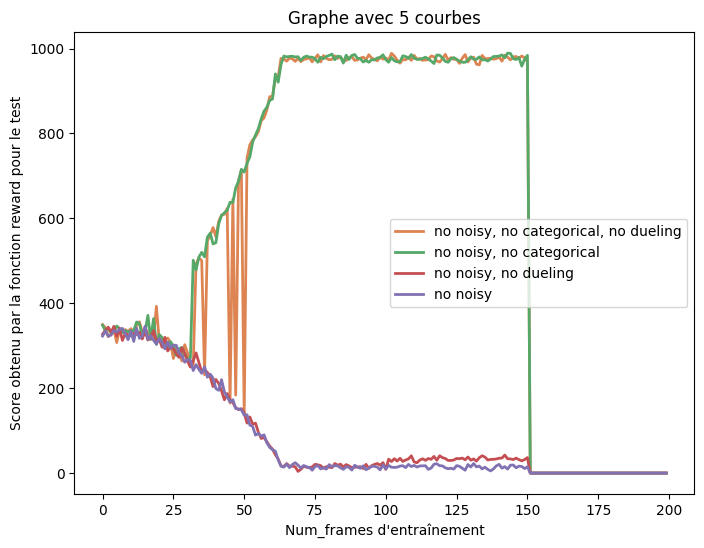

In [27]:
liste_frames = np.arange(num_frames)
liste_label = ["rainbow", "no noisy, no categorical, no dueling", "no noisy, no categorical", "no noisy, no dueling", "no noisy"]
# Générer une palette de 5 couleurs harmonieuses
colors = sns.color_palette("deep", n_colors=len(liste_label))


# Création de la figure et du graphe
plt.figure(figsize=(8, 6))
plt.title("Graphe avec 5 courbes")

# Tracer les courbes
for i in range(1,len(liste_label)):
    plt.plot(liste_frames, score_agents[i], label=liste_label[i], color=colors[i], linewidth=2)

# Ajout de la légende et des labels
plt.xlabel("Num_frames d'entraînement") # QU EST CE QUE NUM FRAMES DANS TRAI?
plt.ylabel("Score obtenu par la fonction reward pour le test")
plt.legend()

# Affichage du graphe
plt.show()